In [ ]:
import pandas as pd
dataset = pd.read_csv("50_Startups.csv")
dataset

In [10]:
dataset=pd.get_dummies(dataset,drop_first=True,dtype=int)
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,0,0


In [11]:
independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend','State_Florida', 'State_New York']]
independent

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,1,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,1,0
5,131876.90,99814.71,362861.36,0,1
6,134615.46,147198.87,127716.82,0,0
7,130298.13,145530.06,323876.68,1,0
8,120542.52,148718.95,311613.29,0,1
9,123334.88,108679.17,304981.62,0,0


In [12]:
dependent=dataset[['Profit']]
dependent

,Profit
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94
5,156991.12
6,156122.51
7,155752.60
8,152211.77
9,149759.96


In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(independent,dependent,test_size=0.30,random_state=0)

In [121]:
from sklearn.tree import DecisionTreeRegressor
regressor= DecisionTreeRegressor(criterion='poisson',splitter='random',max_features='log2')
regressor=regressor.fit(x_train,y_train)

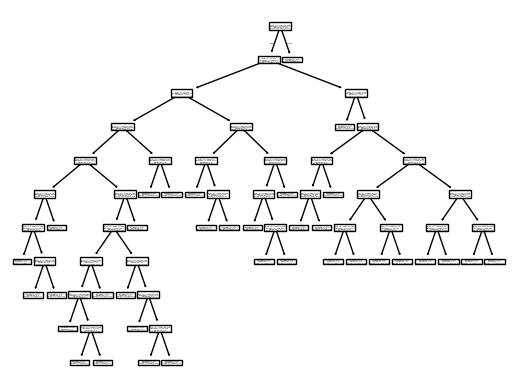

In [122]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()


In [123]:
y_pred = regressor.predict(x_test)

In [124]:
from sklearn.metrics import r2_score
r_score=r2_score(y_test,y_pred)
r_score

-0.5544876996146728

In [125]:
#Pickle is a library to perform object saving and loading to the file related operations
import pickle
fileName="finalized_model_decision_tree.sav"#initialize file name
pickle.dump(regressor,open(fileName,'wb'))#write the model to the given file name(model creation)